<a href="https://colab.research.google.com/github/vandanasri/MLProjectRepo/blob/main/week01/project1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# R1 — Dataset overview

In [6]:
df = pd.read_csv('/content/TitanicEDA/train_titanic.csv')
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
246,247,0,3,"Lindahl, Miss. Agda Thorilda Viktoria",female,25.0,0,0,347071,7.7750,NaN,S
388,389,0,3,"Sadlier, Mr. Matthew",male,NaN,0,0,367655,7.7292,NaN,Q
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.2500,D37,C
486,487,1,1,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90.0000,C93,S
181,182,0,2,"Pernot, Mr. Rene",male,NaN,0,0,SC/PARIS 2131,15.0500,NaN,C
642,643,0,3,"Skoog, Miss. Margit Elizabeth",female,2.0,3,2,347088,27.9000,NaN,S
165,166,1,3,"Goldsmith, Master. Frank John William ""Frankie""",male,9.0,0,2,363291,20.5250,NaN,S
780,781,1,3,"Ayoub, Miss. Banoura",female,13.0,0,0,2687,7.2292,NaN,C
738,739,0,3,"Ivanoff, Mr. Kanio",male,NaN,0,0,349201,7.8958,NaN,S
713,714,0,3,"Larsson, Mr. August Viktor",male,29.0,0,0,7545,9.4833,NaN,S


### R1-1 Shape, column names, dtypes.

In [7]:
# check rows and columns
df.shape

(891, 12)

In [8]:
# All the columns present in dataset
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
# Get dtypes of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


###R1-2  A sentence stating what one row represents uniqueness is PassengerId

In [10]:
# PassengerId id fully unique
df["PassengerId"].is_unique

True

In [11]:
# Get all column names and all columns are labelled and unique.
df.columns.value_counts()

,count
PassengerId,1
Survived,1
Pclass,1
Name,1
Sex,1
Age,1
SibSp,1
Parch,1
Ticket,1
Fare,1


In [12]:
# only numerical columns
df.select_dtypes(include=np.number).columns.tolist()

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [13]:
# Get only the categorical columns
df.select_dtypes(include='object').columns.tolist()

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [14]:
# Count unique values in each categorical column
df.select_dtypes(include='object').nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [15]:
# Count unique values in each numerical column
df.select_dtypes(include=np.number).nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Age,88
SibSp,7
Parch,7
Fare,248


# R2 — Data quality audit

### R2-1 Missing Values


In [16]:
# Total missing values dataset
df.isna().sum().sum()

np.int64(866)

In [17]:
# Missing values per columns
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
# Calculate percentage of missing values for each column
missing_percent = (df.isna().mean() * 100).round(2)

# Keep only columns that actually have missing values
missing_percent = missing_percent[missing_percent > 0]

# Split into two separate variables
column_names = missing_percent.index.tolist()
percentages = missing_percent.values.tolist()
# Display results
print("Columns with missing values:", column_names)
print("Missing percentages:", percentages)

Columns with missing values: ['Age', 'Cabin', 'Embarked']
Missing percentages: [19.87, 77.1, 0.22]


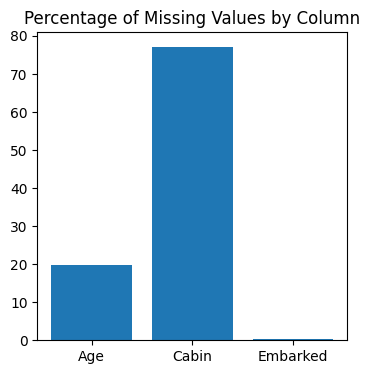

In [19]:
# Below garph which clearly shows missing values
plt.figure(figsize=(4, 4))
plt.bar(column_names,percentages)
plt.title('Percentage of Missing Values by Column')
plt.show()

- There are total 866 missing values in Titanic dataset.
- There are only 3 columns [Cabin, Age, Embarked] which has missing values.
- Cabin has the most 687 missing data with almost 77.1% of missing data.
- Age has 177 missing data with 19.87% in entire 891 rows.
- Embarked has least 2 missing values with 0.22%.
- By above graph it is clearly visible the cabin has the heighest missing value, the cabin and age can effect future prediction.

In [20]:
# Only rows of Pclass where Cabin isn't missing.
df[df['Cabin'].notna()][['Pclass', 'Cabin']]

,Pclass,Cabin
1,1,C85
3,1,C123
6,1,E46
10,3,G6
11,1,C103
...,...,...
871,1,D35
872,1,B51 B53 B55
879,1,C50
887,1,B42


In [21]:
# Getting missing values of Cabin according to the passenger class (Pclass)
missing_pct = df.groupby('Pclass')['Cabin'].apply(lambda x: x.isna().mean() * 100)
missing_pct

,Cabin
Pclass,
1,18.518519
2,91.304348
3,97.556008


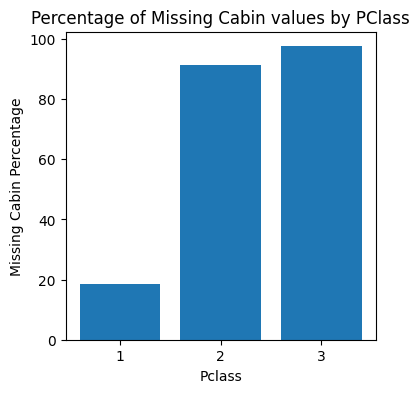

In [22]:
# Below garph which clearly shows missing values of
plt.figure(figsize=(4, 4))
plt.bar(missing_pct.index.astype(str),missing_pct.values)
plt.title('Percentage of Missing Cabin values by PClass')
plt.xlabel('Pclass')
plt.ylabel('Missing Cabin Percentage')
plt.show()

Above graph clearly shows, Pclass has 3 classes [1, 2, 3]. Now, getting the missing values of cabin according to passenger class. According to the observation Pclass-3 has the most missing cabin values almost 97.5, then pclass-2 has 91.3 missing cabins and pclass-1 has the least missing cabin values 18.5.

In [23]:
# Getting missing values of Age according to the passenger class (Pclass)
missing_age_pc = df.groupby('Pclass')['Age'].apply(lambda x: x.isna().mean()*100)
missing_age_pc

,Age
Pclass,
1,13.888889
2,5.978261
3,27.698574


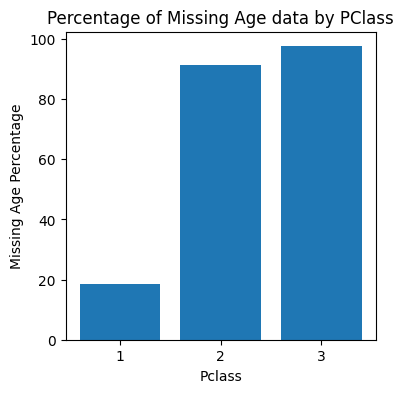

In [24]:
# Below garph which clearly shows missing values of
plt.figure(figsize=(4, 4))
plt.bar(missing_age_pc.index.astype(str),missing_pct.values)
plt.title('Percentage of Missing Age data by PClass')
plt.xlabel('Pclass')
plt.ylabel('Missing Age Percentage')
plt.show()

In [25]:
# To get what all age_group present in every pclass
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

pd.crosstab(df['Pclass'], df['AgeGroup'])

AgeGroup,Child,Teen,Young Adult,Adult,Senior
Pclass,,,,,
1,4,12,66,90,14
2,17,12,94,47,3
3,48,46,198,58,5


In [26]:
# To get percentage of all age_group present in every pclass
age_by_class = pd.crosstab(df['Pclass'], df['AgeGroup'], normalize='index') * 100
age_by_class

AgeGroup,Child,Teen,Young Adult,Adult,Senior
Pclass,,,,,
1,2.150538,6.451613,35.483871,48.387097,7.526882
2,9.826590,6.936416,54.335260,27.167630,1.734104
3,13.521127,12.957746,55.774648,16.338028,1.408451


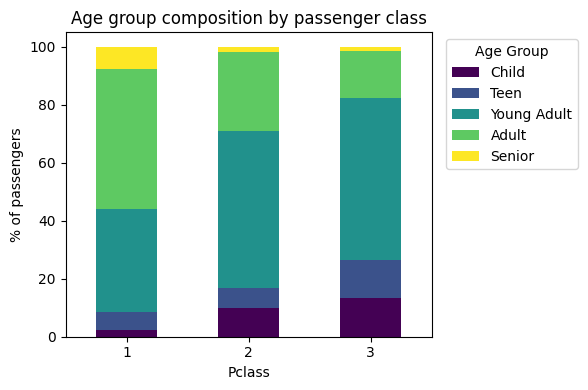

In [27]:
ax = age_by_class.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='viridis')
ax.set_xlabel('Pclass')
ax.set_ylabel('% of passengers')
ax.set_title('Age group composition by passenger class')
ax.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

According to above findings it is obsereved that in titanic has highest numbers of young adults.  

###R2-2 Duplicated rows and duplicated ids

In [28]:
#Checking for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")

#Checking for duplicate ids
duplicate_ids = df["PassengerId"].duplicated().sum()
print(f"Duplicated PassengerId values: {duplicate_ids}")

Fully duplicated rows: 0
Duplicated PassengerId values: 0


No duplicate rows and no duplicate ids — this dataset does not need de-duplication.

### R2-3 — Impossible values (negative ages, future dates, percentages above 100, etc.)

In [29]:
# check Age less than 0 or greater than 100
((df['Age']<0) | (df['Age']>100)).sum()

np.int64(0)

There is no impossible values in Age column

In [30]:
# check if fare is less than 0.0
(df['Fare']<0.0).sum()

np.int64(0)

In [31]:
# check if fare equals 0.0
(df['Fare']==0.0).sum()

np.int64(15)

There is no impossible values in Fare column. There are 15 fare columns which has 0.0 value

In [32]:
# Checking for Impossible sibling/spouse data
(df['SibSp']<0).sum()

np.int64(0)

In [33]:
# Checking for Impossible parent/child data
(df['Parch']<0).sum()

np.int64(0)

In [34]:
# Ticket class check- as pclass has only 3 value, so checking for values other than [1,2,3]
(~df["Pclass"].isin([1, 2, 3])).sum()

np.int64(0)

In [35]:
# Survived check- it has only 2 value, so checking for values other than [0,1]
(~df["Survived"].isin([0, 1])).sum()

np.int64(0)

No impossible values in the dataset

### R2-4 — Sentinel values pretending to be data

In [36]:
zero_fare = df[df["Fare"] == 0]
print(f"Passengers with Fare == 0: {len(zero_fare)}")
zero_fare[["Pclass", "Sex", "Age", "Ticket", "Embarked", "Survived"]]


Passengers with Fare == 0: 15


,Pclass,Sex,Age,Ticket,Embarked,Survived
179,3,male,36.0,LINE,S,0
263,1,male,40.0,112059,S,0
271,3,male,25.0,LINE,S,1
277,2,male,NaN,239853,S,0
302,3,male,19.0,LINE,S,0
413,2,male,NaN,239853,S,0
466,2,male,NaN,239853,S,0
481,2,male,NaN,239854,S,0
597,3,male,49.0,LINE,S,0
633,1,male,NaN,112052,S,0


### R2-5 — Columns with the wrong dtype
`Pclass` [1,2,3] and `Survived` [0,1] (died/survived) are stored as `int64`, but both
are **categorical**, not continuous quantities — `Pclass` is ordinal, `Survived` is
binary.

### R2-6 — Constant or near-constant columns

In [37]:
top_share = (df.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]) * 100).round(1)
top_share.sort_values(ascending=False).to_frame("top_value_share_pct")

,top_value_share_pct
Cabin,77.1
Parch,76.1
Embarked,72.3
SibSp,68.2
Sex,64.8
Survived,61.6
Pclass,55.1
AgeGroup,40.2
Age,19.9
Fare,4.8


In the Titanic data, the highest was Parch at 76.1% — high, but that's just normal class imbalance for a count variable (most people didn't travel with parents/children), not a "useless column" problem. So the finding there was: no constant or near-constant columns exist — which itself is worth stating explicitly rather than assuming.

# R3 Target Analysis

In [38]:
#Check Survived passengers
psurvived=df['Survived'].value_counts()
psurvived

,count
Survived,
0,549
1,342


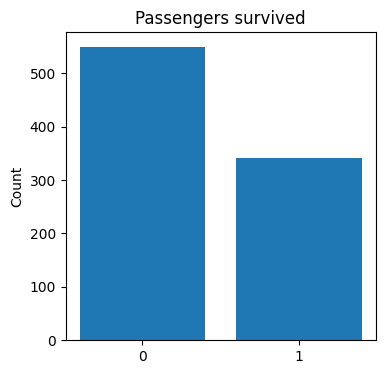

In [39]:
plt.figure(figsize=(4, 4))
plt.bar(psurvived.index.astype(str),psurvived.values)
plt.title('Passengers survived')
plt.ylabel('Count')
plt.show()

There is no missing values in 'Survived' column. 0 means Died and 1 means Survived. There are 891 total passengers travelling in titanic, 342 passengers who survived and rest 549 not survived.

In [40]:
# percentage of people survived
p_survive=(df['Survived'].value_counts(normalize=True) * 100).rename({0: 'Died', 1: 'Survived'})
p_survive

,proportion
Survived,
Died,61.616162
Survived,38.383838


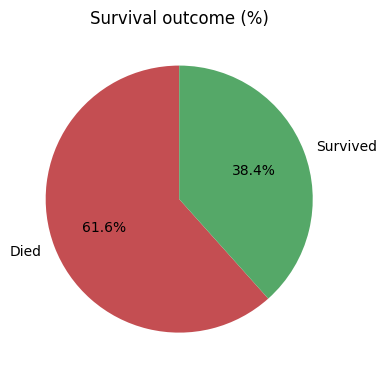

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    p_survive.values,
    labels=['Died', 'Survived'],
    autopct='%1.1f%%',
    colors=['#C44E52', '#55A868'],
    startangle=90
)
ax.set_title('Survival outcome (%)')
plt.tight_layout()
plt.show()

It is clearly visible 61.6% of passengers died and 38.4% of passengers survived.

In [42]:
# Distribution: histogram, mean, median, standard deviation, min, max.

df["Survived"].agg(["mean", "median", "std", "min", "max"])

,Survived
mean,0.383838
median,0.000000
std,0.486592
min,0.000000
max,1.000000


`Survived` has more 0s than 1s. Therefore its mean is 0.384 while its median is 0. But don't treat this as the usual continuous-variable skewness that requires a log transformation. This is mainly telling us that the target classes are imbalanced: 61.6% died and 38.4% survived. When building the model, preserve this ratio using a stratified split and don't judge the model using accuracy alone.

## R4 — Relationships

### R4-1 Correlation matrix of numeric features

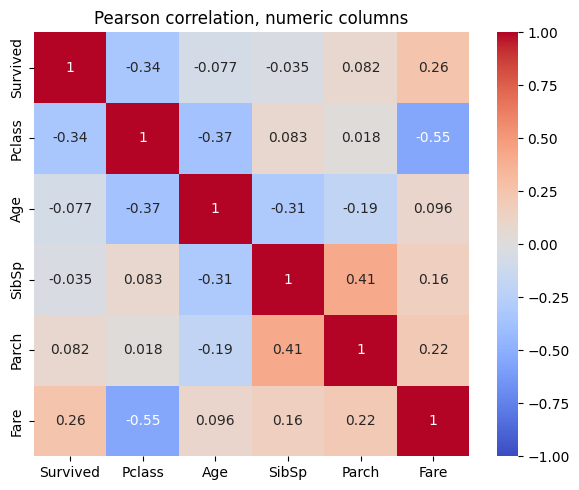

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df.select_dtypes(include='number').drop('PassengerId', axis=1).corr()
sb.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
ax.set_title("Pearson correlation, numeric columns")
plt.tight_layout()
plt.show()

### The required misleading-correlation case

`SibSp`/`Parch` individually show weak linear correlations with `Survived` as it is shown in correlation matrix −0.04 and +0.08. Combined into `FamilySize = SibSp + Parch + 1`, the
**linear** correlation with `Survived` is still essentially zero and not
statistically significant — which would wrongly suggest family size has no bearing
on survival. The actual relationship is strongly **non-linear**.\
Why is it non-linear as shown below:

In [54]:
# Family size = self + siblings/spouse + parents/children

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
family_surv = df.groupby("FamilySize")["Survived"].agg(["mean", "count"])
family_surv["mean_pct"] = (family_surv["mean"] * 100).round(1)
family_surv

,mean,count,mean_pct
FamilySize,,,
1,0.303538,537,30.4
2,0.552795,161,55.3
3,0.578431,102,57.8
4,0.724138,29,72.4
5,0.200000,15,20.0
6,0.136364,22,13.6
7,0.333333,12,33.3
8,0.000000,6,0.0
11,0.000000,7,0.0


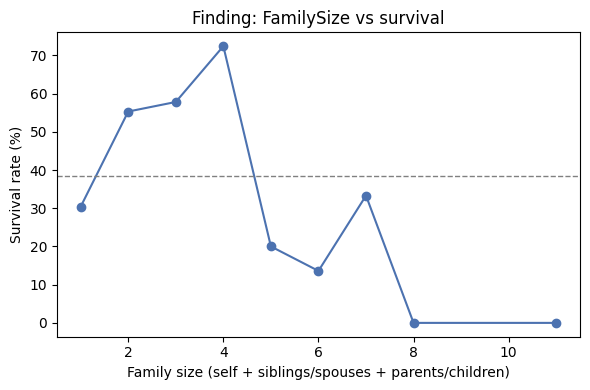

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(family_surv.index, plot_fam["mean_pct"], marker="o", color="#4C72B0")
ax.set_xlabel("Family size (self + siblings/spouses + parents/children)")
ax.set_ylabel("Survival rate (%)")
ax.set_title("Finding: FamilySize vs survival")
ax.axhline(df["Survived"].mean() * 100, color="gray", linestyle="--", linewidth=1, label="Overall survival rate")
plt.tight_layout()
plt.show()

Solo travellers (family size 1) survived at 30.4%, family sizes 2–4 survived at
55–72%, and family sizes ≥5 dropped back to 0–33%. And large family rate is worse.

### R4-2 Target against at least four features

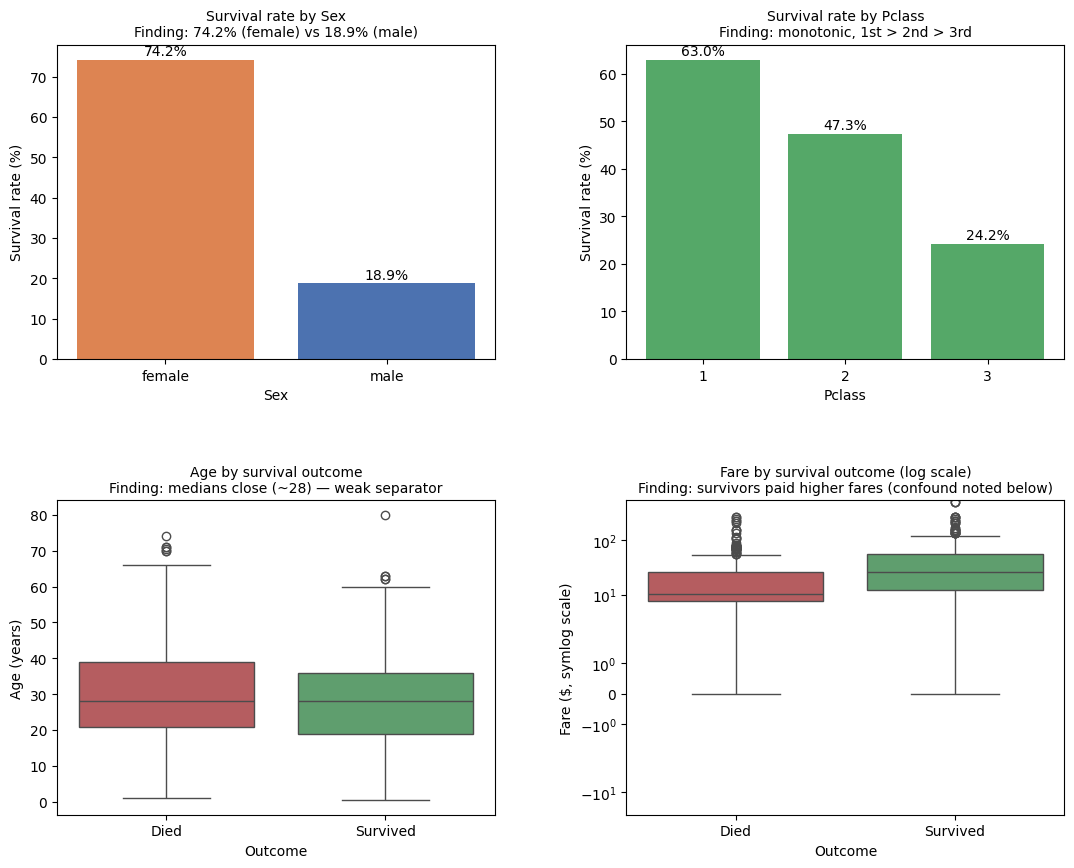

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Sex (categorical) -> survival rate bar
sex_rate = df.groupby("Sex")["Survived"].mean() * 100
axes[0, 0].bar(sex_rate.index, sex_rate.values, color=["#DD8452", "#4C72B0"])
axes[0, 0].set_title("Survival rate by Sex\nFinding: 74.2% (female) vs 18.9% (male)", fontsize=10)
axes[0, 0].set_ylabel("Survival rate (%)")
axes[0, 0].set_xlabel("Sex")
for i, v in enumerate(sex_rate.values):
    axes[0, 0].text(i, v + 1, f"{v:.1f}%", ha="center")

# 2. Pclass (categorical) -> survival rate bar
pclass_rate = df.groupby("Pclass")["Survived"].mean() * 100
axes[0, 1].bar(pclass_rate.index.astype(str), pclass_rate.values, color="#55A868")
axes[0, 1].set_title("Survival rate by Pclass\nFinding: monotonic, 1st > 2nd > 3rd", fontsize=10)
axes[0, 1].set_ylabel("Survival rate (%)")
axes[0, 1].set_xlabel("Pclass")
for i, v in enumerate(pclass_rate.values):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center")

# 3. Age (numeric) -> boxplot split by Survived
sb.boxplot(data=df, x="Survived", y="Age", hue="Survived", palette=["#C44E52", "#55A868"],
           legend=False, ax=axes[1, 0])
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["Died", "Survived"])
axes[1, 0].set_title("Age by survival outcome\nFinding: medians close (~28) — weak separator", fontsize=10)
axes[1, 0].set_xlabel("Outcome")
axes[1, 0].set_ylabel("Age (years)")

# 4. Fare (numeric) -> boxplot split by Survived (log scale, since heavily skewed)
sb.boxplot(data=df, x="Survived", y="Fare", hue="Survived", palette=["#C44E52", "#55A868"],
           legend=False, ax=axes[1, 1])
axes[1, 1].set_yscale("symlog")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Died", "Survived"])
axes[1, 1].set_title("Fare by survival outcome (log scale)\nFinding: survivors paid higher fares (confound noted below)", fontsize=10)
axes[1, 1].set_xlabel("Outcome")
axes[1, 1].set_ylabel("Fare ($, symlog scale)")

plt.subplots_adjust(wspace=0.3, hspace=0.45)
plt.show()


In [48]:
# Checking embarked servival rate
embarked_rate = df.groupby("Embarked")["Survived"].mean() * 100
print("Survival rate by Embarked (5th feature, for completeness):")
print(embarked_rate.round(1))

Survival rate by Embarked (5th feature, for completeness):
Embarked
C    55.4
Q    39.0
S    33.7
Name: Survived, dtype: float64


Embarked: records which port a passenger boarded the Titanic from.

Code	Port and their servival rate:-
S	Southampton, England — 55.4%
C	Cherbourg, France - 39%
Q	Queenstown, Ireland - 33.7%

The Embarked column with almost no missing data — just 2 rows out of 891.